In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'SimHei'

In [2]:
i = 0
dp = "C:/Users/snong/Desktop/20260514_YAK_Data/"
files = os.listdir(dp)
fp = os.path.join(dp, files[i])
df = pd.read_csv(fp)

In [3]:
df['hr'] = 60000. / df.rri
df['hr'] = df.hr.astype(int)
df

,record_time,sub_index,rri,area_up,area_down,motion,hr
0,2025-03-12 09:04:25,0,750,7,212,938,80
1,2025-03-12 09:04:25,1,610,5,210,375,98
2,2025-03-12 09:04:26,0,760,3,208,57,78
3,2025-03-12 09:04:27,0,870,1,206,40,68
4,2025-03-12 09:04:28,0,900,0,204,7,66
...,...,...,...,...,...,...,...
104059,2025-03-13 08:29:47,1,790,405,583,4,75
104060,2025-03-13 08:29:48,0,690,405,583,5,86
104061,2025-03-13 08:29:49,0,660,405,583,7,90
104062,2025-03-13 08:29:50,0,660,405,583,3,90


In [4]:
time = pd.to_datetime(df.record_time, format="%Y-%m-%d %H:%M:%S").astype('datetime64[s]').astype('int64')
time

0         1741770265
1         1741770265
2         1741770266
3         1741770267
4         1741770268
             ...    
104059    1741854587
104060    1741854588
104061    1741854589
104062    1741854590
104063    1741854590
Name: record_time, Length: 104064, dtype: int64

In [5]:
dt = time.diff()

In [6]:
gap = np.where(dt > 1)[0]

In [7]:
gap

array([14592, 19776, 34080, 36288, 46368, 48672, 50880, 99931, 99991])

In [8]:
dt[gap]

14592     68.0
19776     71.0
34080     73.0
36288     85.0
46368     70.0
48672     78.0
50880     78.0
99931    112.0
99991     83.0
Name: record_time, dtype: float64

In [9]:
df

,record_time,sub_index,rri,area_up,area_down,motion,hr
0,2025-03-12 09:04:25,0,750,7,212,938,80
1,2025-03-12 09:04:25,1,610,5,210,375,98
2,2025-03-12 09:04:26,0,760,3,208,57,78
3,2025-03-12 09:04:27,0,870,1,206,40,68
4,2025-03-12 09:04:28,0,900,0,204,7,66
...,...,...,...,...,...,...,...
104059,2025-03-13 08:29:47,1,790,405,583,4,75
104060,2025-03-13 08:29:48,0,690,405,583,5,86
104061,2025-03-13 08:29:49,0,660,405,583,7,90
104062,2025-03-13 08:29:50,0,660,405,583,3,90


In [10]:
df_m = df[df.hr > 100]
df_m

,record_time,sub_index,rri,area_up,area_down,motion,hr
12,2025-03-12 09:04:34,0,560,7,192,2,107
17,2025-03-12 09:04:37,1,510,12,187,2,117
18,2025-03-12 09:04:38,0,520,15,186,2,115
19,2025-03-12 09:04:38,1,540,16,185,1,111
31,2025-03-12 09:04:48,0,570,13,180,4,105
...,...,...,...,...,...,...,...
104030,2025-03-13 08:29:26,1,550,405,583,7,109
104031,2025-03-13 08:29:27,0,550,405,583,2,109
104032,2025-03-13 08:29:28,0,570,405,583,23,105
104037,2025-03-13 08:29:31,0,590,405,583,4,101


In [11]:
df_m.area_up.value_counts().sort_index()

area_up
2       1
4       1
7       1
9       1
10      3
       ..
2131    1
2133    1
2504    1
2597    1
2626    1
Name: count, Length: 1151, dtype: int64

In [12]:
df.area_up.value_counts().sort_index()

area_up
0        2
1        2
2        9
3       14
4        9
        ..
3426     4
3427     4
3428     7
3429     9
3430    13
Name: count, Length: 3291, dtype: int64

<Axes: >

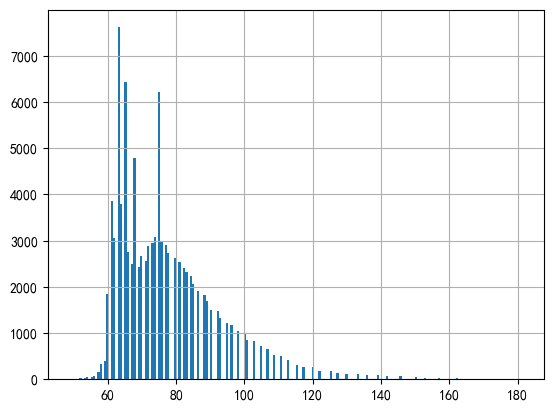

In [13]:
df.hr.hist(bins=200)

In [18]:
print(df[["area_up", "area_down"]].describe())

             area_up      area_down
count  104064.000000  104064.000000
mean     1204.083910    1954.797250
std       838.631434    1426.810579
min         0.000000     180.000000
25%       497.000000     778.000000
50%       850.000000    1301.000000
75%      1879.000000    3065.000000
max      3430.000000    6227.000000
